In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("mobile_data")

In [ ]:
import os
os.listdir("mobile_data")

['test.csv', 'train.csv']

In [ ]:
import pandas as pd
train = pd.read_csv("mobile_data/train.csv")
train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
train.shape

(2000, 21)

In [ ]:
train.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [ ]:
x=train.drop("price_range",axis=1)
y=train["price_range"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state=42)

In [ ]:
model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred =model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

accuracy: 0.8925


In [ ]:
X.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object')

In [ ]:
new_phone = [[
    1500, 1, 2.0, 1, 8, 1, 32, 0.5, 150,
    4, 12, 800, 1280, 2048, 15, 8, 12, 1, 1, 1
]]

In [ ]:
prediction=model.predict(new_phone)
print("predicted price range: ",prediction[0])

predicted price range:  2


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

,0
ram,0.470962
battery_power,0.074796
px_height,0.058538
px_width,0.056722
mobile_wt,0.041434
int_memory,0.037928
talk_time,0.032441
pc,0.030745
clock_speed,0.029058
sc_h,0.028447


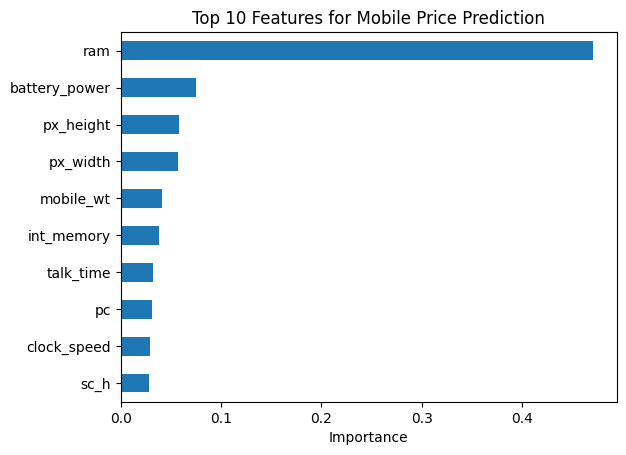

In [ ]:
import matplotlib.pyplot as plt

importance.head(10).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.title("Top 10 Features for Mobile Price Prediction")
plt.show()

In [ ]:
def predict_phone_price(phone):
    prediction = model.predict([phone])
    return prediction[0]

In [ ]:
price = predict_phone_price(new_phone[0])

print("Predicted price range:", price)

Predicted price range: 2


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
price_categories = {
    0: "Low",
    1: "Medium",
    2: "High",
    3: "Very High"
}

In [ ]:
print("Predicted price category: :", price_categories[price])

Predicted price category: : High


In [ ]:
ram = float(input("Enter RAM: "))

print("RAM:", ram)


Enter RAM: 4566
RAM: 4566.0


In [ ]:
features = X.columns.tolist()

print(features)

['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']


In [ ]:
phone_values = []

for feature in features:
    value = float(input(f"Enter {feature}: "))
    phone_values.append(value)

print(phone_values)

Enter battery_power: 2000
Enter blue: 0
Enter clock_speed: 2.0
Enter dual_sim: 1
Enter fc: 8
Enter four_g: 1
Enter int_memory: 64
Enter m_dep: 0.5
Enter mobile_wt: 150
Enter n_cores: 4
Enter pc: 12
Enter px_height: 800
Enter px_width: 1280
Enter ram: 4096
Enter sc_h: 15
Enter sc_w: 8
Enter talk_time: 12
Enter three_g: 1
Enter touch_screen: 1
Enter wifi: 1
[2000.0, 0.0, 2.0, 1.0, 8.0, 1.0, 64.0, 0.5, 150.0, 4.0, 12.0, 800.0, 1280.0, 4096.0, 15.0, 8.0, 12.0, 1.0, 1.0, 1.0]


In [ ]:
new_prediction = predict_phone_price(phone_values)

print("Predicted Price Range:", new_prediction)

Predicted Price Range: 3


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("Predicted Price Category:", price_categories[new_prediction])

Predicted Price Category: Very High
